# Module 27 – Cardiac Diagnostics Case Study

## Cardiac Disease Prediction Model

In this case study, I am using a heart disease dataset to build a machine learning classification model. The main aim is to use patient information such as age, blood pressure, cholesterol and other medical measurements to predict the target value.

I will first understand the data, clean and prepare it, then train a Logistic Regression model and check how well it performs.

## 1. Import the Required Libraries

First, I am importing the libraries that I need for reading the data, preprocessing it, building the model and checking the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## 2. Load the Dataset

The dataset provided for this assignment is a CSV file. I am loading it using pandas and checking the first few rows to understand what kind of data it contains.

In [2]:
df = pd.read_csv("heart (1).csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Check the Size of the Dataset

Here I am checking the number of rows and columns. This gives me a quick idea about the size of the dataset.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 303
Number of columns: 14


The dataset has **303 rows and 14 columns**. There are 13 input features and one target column.

## 4. Check the Column Names

I am displaying all the column names so that I can understand what information is available in the dataset.

In [4]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


The columns include information such as age, sex, chest pain type, resting blood pressure, cholesterol, maximum heart rate and other medical measurements. The `target` column is the value that the model needs to predict.

## 5. Check the Data Types

Next, I am checking the data type of each column. This is useful before starting the preprocessing because some columns may need to be converted or encoded.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


The dataset mainly contains integer values, with `oldpeak` stored as a decimal value. The categorical variables are represented using numbers, so I will treat the category-type columns separately during preprocessing.

## 6. Check for Missing Values

Before training the model, I need to make sure there are no missing values in the dataset.

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


There are no missing values in the dataset, so no missing-value treatment is required for this file.

## 7. Check for Duplicate Rows

Duplicate records can affect the model, so I am checking whether the dataset contains any duplicate rows.

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


There are no duplicate rows in the dataset, so I can continue with the data as it is.

## 8. Basic Statistical Summary

I am using `describe()` to get a basic summary of the numerical columns. This helps me see values such as the average, minimum and maximum.

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


This gives a quick overview of the ranges of the different features. For example, age, cholesterol and maximum heart rate are measured on very different scales, which is one reason why scaling will be useful for Logistic Regression.

## 9. Understand the Target Column

The `target` column is the output that the model is going to predict. I am checking how many records belong to each target class.

In [9]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True) * 100)

target
1    165
0    138
Name: count, dtype: int64

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


The target contains two classes, so this is a **binary classification** problem. The model will predict either `0` or `1`.

## 10. Visualize the Target Distribution

I am creating a simple bar chart to see the number of records in each target class.

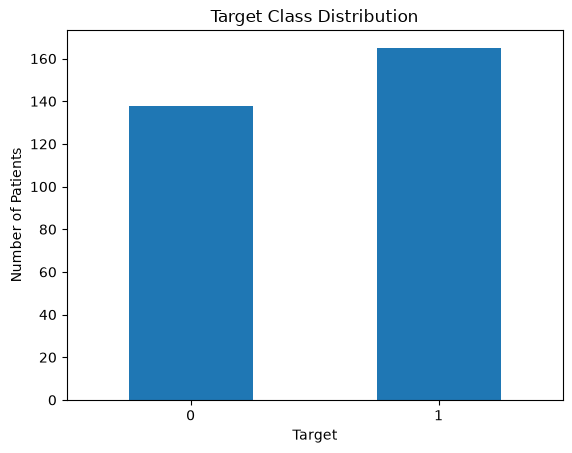

In [10]:
df["target"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.title("Target Class Distribution")
plt.xticks(rotation=0)
plt.show()

The two target classes are reasonably represented in the dataset. I will also use a stratified train-test split so that both classes are represented in a similar proportion in the training and testing data.

## 11. Check Important Numerical Features

I am looking at a few of the main numerical health measurements to understand their ranges.

In [11]:
df[["age", "trestbps", "chol", "thalach", "oldpeak"]].describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


The features have different ranges. For example, cholesterol and blood pressure have larger numerical values than `oldpeak`. Scaling the numerical features will help Logistic Regression work with these differences in scale.

## 12. Separate Input Features and Target

Now I am separating the dataset into `X` and `y`.

- `X` contains the information used to make the prediction.
- `y` contains the actual target value.

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


## 13. Select Numerical and Categorical Columns

Some columns represent measurements, while others represent categories encoded as numbers. I am separating them so that I can apply the correct preprocessing to each group.

In [13]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


The numerical columns will be standardized using `StandardScaler`. The categorical columns will be converted into separate binary columns using one-hot encoding.

## 14. Split the Data into Training and Testing Sets

I am using 80% of the data for training and 20% for testing. I am also using `stratify=y` so that the class distribution stays similar in both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


The training data will be used to learn the relationship between the patient features and the target. The testing data will be kept separate and used only to check the final model performance.

## 15. Create the Preprocessing Steps

Here I am creating a preprocessing pipeline.

For the numerical columns, I use standardization. For the categorical columns, I use one-hot encoding. `handle_unknown="ignore"` makes the preprocessing safer if an unseen category appears in the test data.

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_columns)
    ]
)

## 16. Create the Logistic Regression Model

I am using **Logistic Regression** because this is a binary classification problem. The model will learn from the training data and predict whether the target is 0 or 1.

In [16]:
model = LogisticRegression(max_iter=1000)

## 17. Build the Complete Pipeline

I am combining the preprocessing steps and the Logistic Regression model into one pipeline. This also helps keep the preprocessing and model training together.

In [17]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

## 18. Train the Model

Now I am fitting the pipeline on the training data. This is where the model learns from the available examples.

In [18]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


The model has now been trained using the training dataset.

## 19. Make Predictions on the Test Data

After training, I am using the test data to see what the model predicts for records it has not seen during training.

In [19]:
y_pred = pipeline.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 1 0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1]


These are the first 20 predictions made by the model. The predictions are either `0` or `1` because this is a binary classification problem.

## 20. Calculate Accuracy

Accuracy tells me the percentage of test records that were classified correctly.

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.8688524590163934
Accuracy percentage: 86.88524590163934


For this run, the model gets an accuracy of about **86.89%** on the test data.

## 21. Create the Confusion Matrix

A confusion matrix shows the correct and incorrect predictions in more detail. It separates the results into true negatives, false positives, false negatives and true positives.

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23  5]
 [ 3 30]]


The confusion matrix can be read as:

- Top-left: correctly predicted class 0
- Top-right: class 0 predicted as class 1
- Bottom-left: class 1 predicted as class 0
- Bottom-right: correctly predicted class 1

## 22. Display the Confusion Matrix as a Chart

A simple chart makes the confusion matrix easier to read.

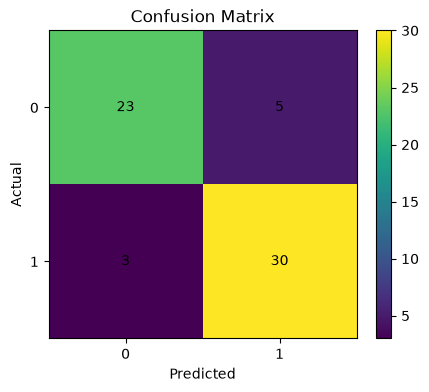

In [22]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

For this test split, the confusion matrix is:

- 23 records were correctly predicted as class 0.
- 30 records were correctly predicted as class 1.
- 5 records from class 0 were predicted as class 1.
- 3 records from class 1 were predicted as class 0.

## 23. Calculate Precision

Precision tells me, among the records predicted as positive, how many were actually positive.

In [23]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8571428571428571


The precision for this test set is about **0.8571**, or **85.71%**.

## 24. Calculate Recall

Recall tells me how many of the actual positive records were correctly identified by the model.

In [24]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.9090909090909091


The recall for this test set is about **0.9091**, or **90.91%**.

## 25. Calculate F1-Score

The F1-score combines precision and recall into one measure. It is useful when I want to look at both of these measures together.

In [25]:
f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.8823529411764706


The F1-score for this test set is about **0.8824**, or **88.24%**.

## 26. Generate the Classification Report

The classification report gives precision, recall and F1-score together for the two classes.

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        28
           1       0.86      0.91      0.88        33

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



This gives a more complete view of the model than accuracy alone because it shows how the model performs for each class.

## 27. Store the Main Evaluation Results

I am putting the main scores into a small table so they are easy to compare.

In [27]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

results

,Metric,Score
0,Accuracy,0.868852
1,Precision,0.857143
2,Recall,0.909091
3,F1-score,0.882353


## 28. Final Comparison of Actual and Predicted Values

I am creating a small table containing the actual target and the predicted target for the test data. This helps me see individual predictions.

In [28]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,1
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,0,0


Some predictions match the actual values and some do not. This is normal for a machine learning model, and the evaluation metrics above show the overall performance on the test data.

## 29. Final Observations and Findings

The Logistic Regression model was trained to predict the target value using patient information from the heart disease dataset.

For the test data, the model produced the following results:

- **Accuracy:** 86.89%
- **Precision:** 85.71%
- **Recall:** 90.91%
- **F1-score:** 88.24%

The confusion matrix showed **23 true negatives, 5 false positives, 3 false negatives and 30 true positives**.

Overall, the model was able to classify most of the test records correctly. The recall was higher than the precision in this particular test run, meaning the model correctly identified a larger share of the actual positive cases than the share of its positive predictions that were correct.

This case study helped me understand the complete classification workflow, starting from exploring the dataset and preprocessing the features, then training a Logistic Regression model and finally checking its performance using different evaluation metrics.

These results are specific to this dataset, preprocessing method and train-test split. A machine learning prediction from this exercise should not be treated as a medical diagnosis.

## 30. Conclusion

In this module, I worked with a cardiac disease dataset and built a binary classification model using Logistic Regression.

I completed the main steps of the case study:

1. Imported and explored the dataset.
2. Checked for missing and duplicate values.
3. Separated numerical and categorical features.
4. Standardized numerical features.
5. Encoded categorical features.
6. Split the data into training and testing sets.
7. Trained a Logistic Regression model.
8. Evaluated the model using accuracy, confusion matrix, precision, recall and F1-score.

The final test accuracy was **86.89%**, showing that the model was able to make correct predictions for most of the test records.

# Colab Link

https://colab.research.google.com/drive/1v5IXEQMuPb3wTNaaszLGd-LPREoh0EJJ?usp=sharing